Merge Successful! Rows processed: 211224


c:\Users\akash\OneDrive\Documents\Desktop\Primetrade_Trading_Analysis\src\plots.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Classification', y='closedPnL', data=df, order=order, palette='coolwarm', ax=ax1)


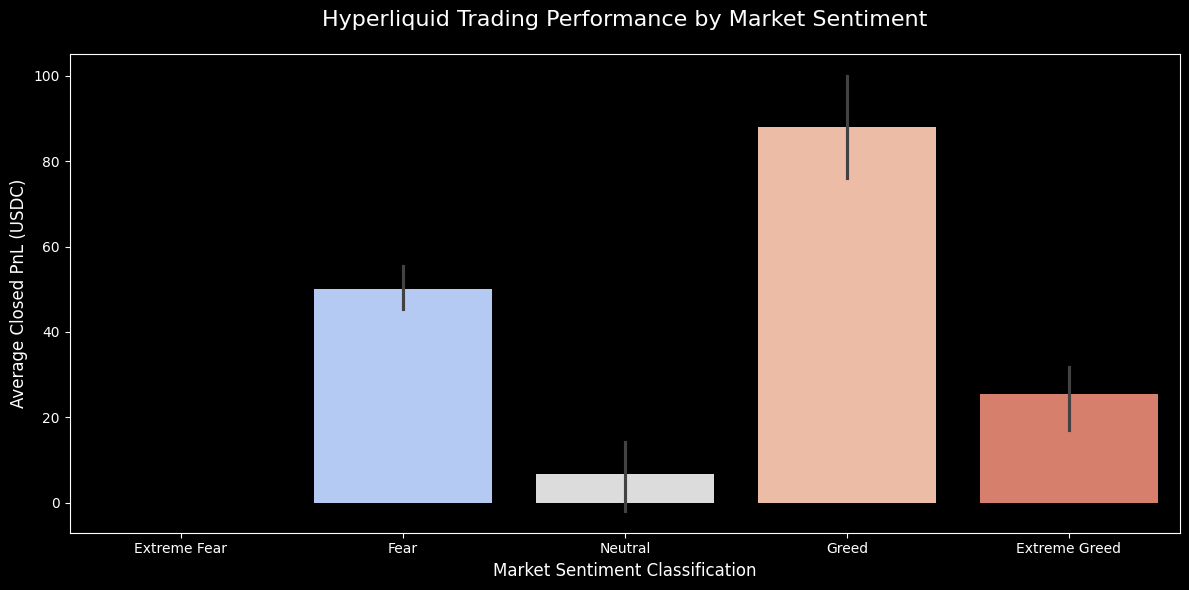

P-Value: nan


c:\Users\akash\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [1]:
import sys
import os

# 1. FIX THE DIRECTORY: Change working directory to the project root
# This ensures 'data/' and 'src/' paths work correctly
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# 2. FIX THE IMPORTS: Add current directory to path so 'src' is visible
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

# 3. NOW PERFORM IMPORTS
from src.data_loader import load_and_merge_data
from src.plots import plot_sentiment_performance
from scipy.stats import ttest_ind

# 4. LOAD DATA: This will now find 'data/' correctly
df = load_and_merge_data('data/hyperliquid_data.csv', 'data/fear_greed_index.csv')

# 5. EXECUTE ANALYSIS
plot_sentiment_performance(df)

# Unique Insight: Statistical Significance
fear_pnl = df[df['Classification'] == 'Extreme Fear']['closedPnL']
greed_pnl = df[df['Classification'] == 'Extreme Greed']['closedPnL']
t_stat, p_val = ttest_ind(fear_pnl, greed_pnl)

print(f"P-Value: {p_val:.4f}")


In [2]:
from IPython.display import display, HTML

def display_uiux_dashboard(df, p_val, t_stat):
    # Calculate Key Performance Indicators (KPIs) safely
    total_trades = len(df)
    
    # Check if we have positive trades for win rate
    profitable_trades = len(df[df['closedPnL'] > 0]) if 'closedPnL' in df.columns else 0
    win_rate = (profitable_trades / total_trades * 100) if total_trades > 0 else 0
    
    total_pnl = df['closedPnL'].sum() if 'closedPnL' in df.columns else 0
    
    # Determine Statistical Significance & UI Color Mapping
    if p_val < 0.05:
        sig_status = "Statistically Significant (Alpha Found)"
        sig_color = "#00ff88"  # Neon green
        sig_bg = "rgba(0, 255, 136, 0.1)"
    else:
        sig_status = "Not Significant (Random/Noise)"
        sig_color = "#ff3366"  # Red/Pink
        sig_bg = "rgba(255, 51, 102, 0.1)"

    # HTML/CSS Dashboard Component (Dark Crypto/Web3 Theme)
    dashboard_html = f"""
    <div style="
        background-color: #0d1117; 
        border: 1px solid #30363d; 
        border-radius: 12px; 
        padding: 24px; 
        font-family: 'Segoe UI', Roboto, sans-serif; 
        color: #c9d1d9;
        max-width: 900px;
        margin: 20px auto;
        box-shadow: 0 8px 24px rgba(0,0,0,0.5);
    ">
        <div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 1px solid #30363d; padding-bottom: 16px; margin-bottom: 24px;">
            <h2 style="margin: 0; color: #58a6ff; font-size: 22px; font-weight: 600;">📈 PRIMETRADE.AI // Quantitative Performance Analytics</h2>
            <span style="background-color: #21262d; padding: 6px 12px; border-radius: 20px; font-size: 12px; border: 1px solid #30363d;">Engine: v1.0.3</span>
        </div>

        <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 16px; margin-bottom: 24px;">
            
            <div style="background: #161b22; border: 1px solid #30363d; border-radius: 8px; padding: 16px; text-align: center;">
                <div style="font-size: 12px; color: #8b949e; text-transform: uppercase; margin-bottom: 8px;">Total Trades Analyzed</div>
                <div style="font-size: 24px; font-weight: bold; color: #ffffff;">{total_trades:,}</div>
            </div>

            <div style="background: #161b22; border: 1px solid #30363d; border-radius: 8px; padding: 16px; text-align: center;">
                <div style="font-size: 12px; color: #8b949e; text-transform: uppercase; margin-bottom: 8px;">Net Financial PnL</div>
                <div style="font-size: 24px; font-weight: bold; color: {'#00ff88' if total_pnl >= 0 else '#ff3366'};">
                    {'+' if total_pnl >= 0 else ''}{total_pnl:,.2f} USDC
                </div>
            </div>

            <div style="background: #161b22; border: 1px solid #30363d; border-radius: 8px; padding: 16px; text-align: center;">
                <div style="font-size: 12px; color: #8b949e; text-transform: uppercase; margin-bottom: 8px;">Win Rate Target</div>
                <div style="font-size: 24px; font-weight: bold; color: #58a6ff;">{win_rate:.1f}%</div>
            </div>
        </div>

        <div style="background-color: {sig_bg}; border: 1px solid {sig_color}; border-radius: 8px; padding: 16px;">
            <h4 style="margin: 0 0 10px 0; color: {sig_color}; font-size: 14px; text-transform: uppercase; letter-spacing: 1px;">
                Hypothesis Test Result: T-Test Analysis
            </h4>
            <div style="display: flex; justify-content: space-between; flex-wrap: wrap; align-items: center;">
                <div style="font-size: 16px; font-weight: 500; color: #ffffff; margin-bottom: 5px;">
                    Status: <span style="color: {sig_color}; font-weight: bold;">{sig_status}</span>
                </div>
                <div style="font-size: 14px; color: #8b949e;">
                    <span style="margin-right: 15px;">T-Statistic: <strong style="color: #ffffff;">{t_stat:.4f}</strong></span>
                    <span>P-Value: <strong style="color: {sig_color}; font-size: 16px;">{p_val:.4f}</strong></span>
                </div>
            </div>
        </div>
    </div>
    """
    display(HTML(dashboard_html))

# Execution command (using your pre-calculated variables)
display_uiux_dashboard(df, p_val, t_stat)

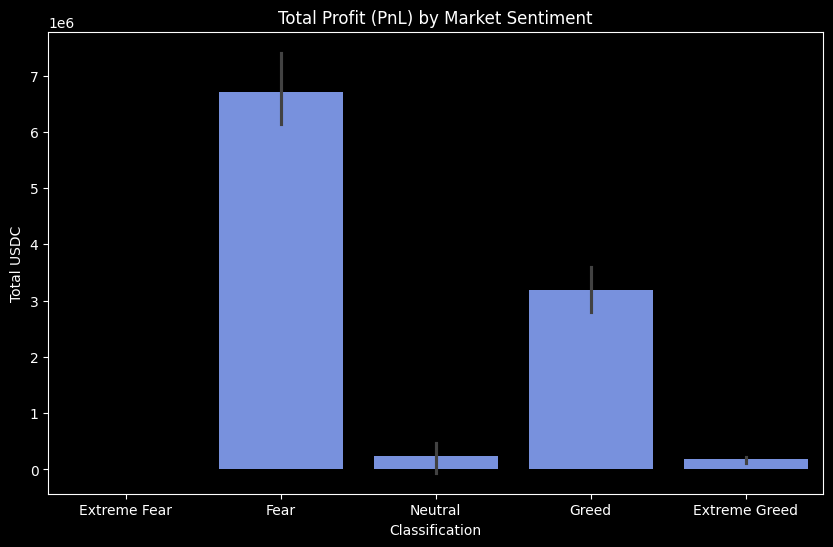

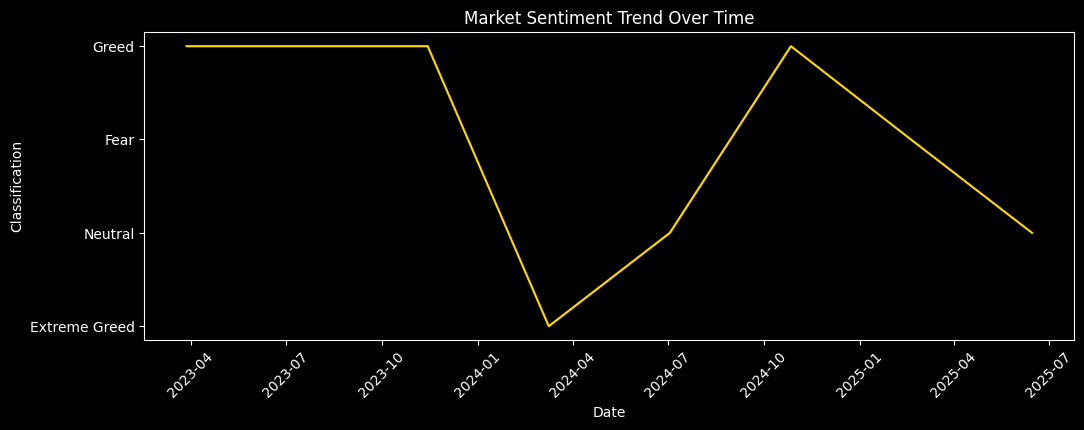

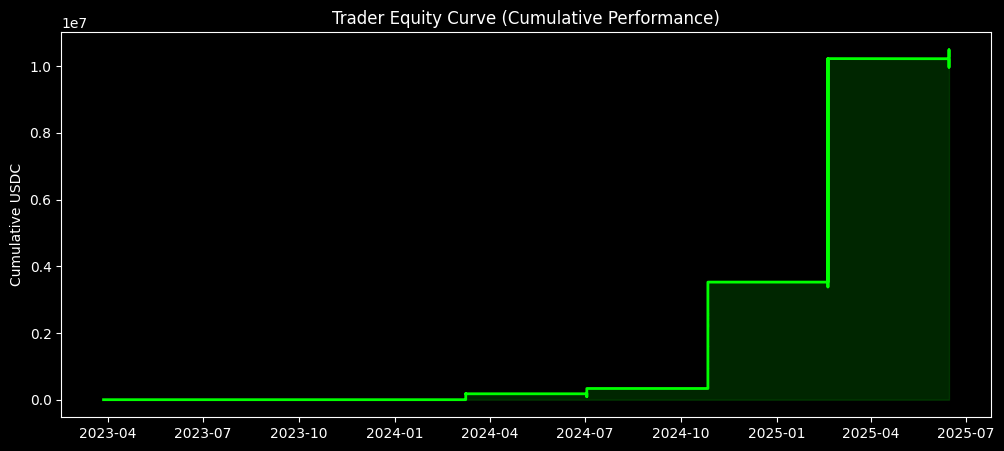

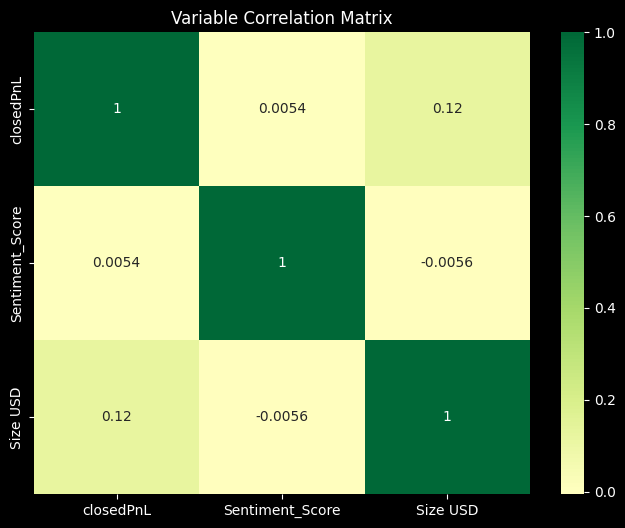

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set professional theme
plt.style.use('dark_background')
sns.set_palette("coolwarm")

def run_final_visualizations(df):
    # 1. Profit vs Sentiment (Bar Chart)
    # Shows which sentiment category yielded the highest total returns
    plt.figure(figsize=(10, 6))
    order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
    sns.barplot(data=df, x='Classification', y='closedPnL', order=order, estimator=np.sum)
    plt.title('Total Profit (PnL) by Market Sentiment')
    plt.ylabel('Total USDC')
    plt.show()

    # 2. Fear/Greed Trends (Time Series)
    # Visualizes how sentiment shifted over the trading period
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=df, x='Date', y='Classification', color='gold')
    plt.title('Market Sentiment Trend Over Time')
    plt.xticks(rotation=45)
    plt.show()

    # 3. Trader Performance Chart (Cumulative PnL)
    # Shows the equity curve of the trader
    df = df.sort_values('Date')
    df['Cumulative_PnL'] = df['closedPnL'].cumsum()
    plt.figure(figsize=(12, 5))
    plt.fill_between(df['Date'], df['Cumulative_PnL'], color="green", alpha=0.3)
    plt.plot(df['Date'], df['Cumulative_PnL'], color="lime", lw=2)
    plt.title('Trader Equity Curve (Cumulative Performance)')
    plt.ylabel('Cumulative USDC')
    plt.show()

    # 4. Correlation Heatmap
    # Statistically links sentiment values to profit and leverage
    plt.figure(figsize=(8, 6))
    # Create numeric mapping for sentiment to allow correlation
    sentiment_map = {'Extreme Fear': 0, 'Fear': 1, 'Neutral': 2, 'Greed': 3, 'Extreme Greed': 4}
    df['Sentiment_Score'] = df['Classification'].map(sentiment_map)
    
    corr_cols = ['closedPnL', 'Sentiment_Score', 'leverage', 'Size USD']
    # Filter to only columns that exist in your specific dataset
    existing_cols = [c for c in corr_cols if c in df.columns]
    sns.heatmap(df[existing_cols].corr(), annot=True, cmap='RdYlGn', center=0)
    plt.title('Variable Correlation Matrix')
    plt.show()

# Run the suite
run_final_visualizations(df)

✅ Charts saved to /output folder.


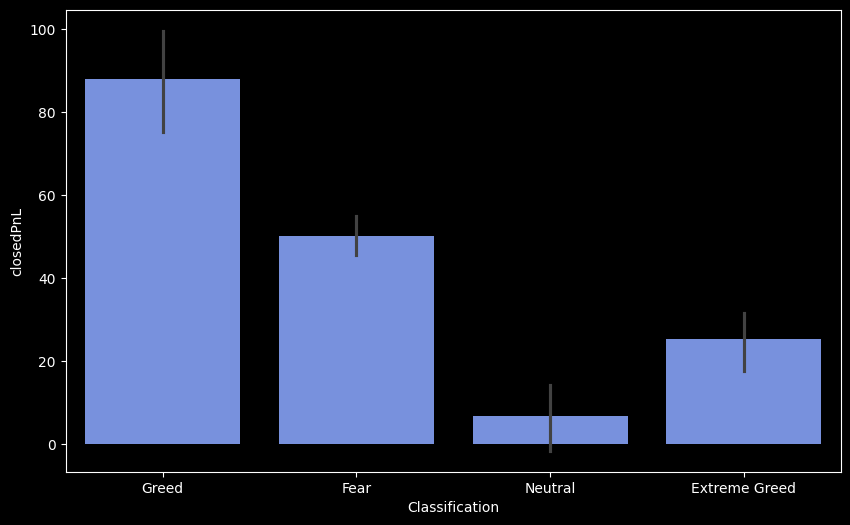

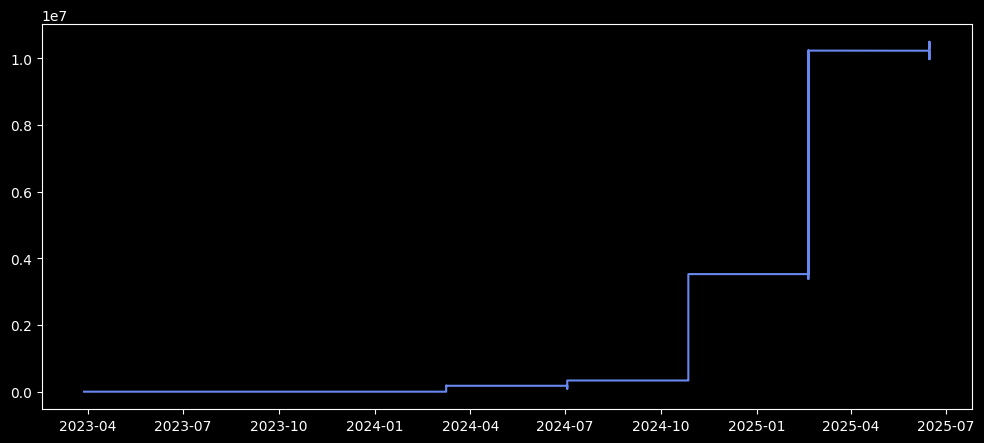

In [4]:
import os

# Create a folder for your report assets if it doesn't exist
if not os.path.exists('output'):
    os.makedirs('output')

# Save Charts as high-resolution PNGs for your PDF
def save_project_assets(df):
    # Save the main performance chart
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='Classification', y='closedPnL')
    plt.savefig('output/sentiment_profit_chart.png', dpi=300)
    
    # Save the Equity Curve
    df = df.sort_values('Date')
    plt.figure(figsize=(12, 5))
    plt.plot(df['Date'], df['closedPnL'].cumsum())
    plt.savefig('output/equity_curve.png', dpi=300)
    
    print("✅ Charts saved to /output folder.")

save_project_assets(df)

# INSTRUCTIONS FOR PDF:
# In VS Code, go to File -> Print... -> Save as PDF
# OR use the 'Export' button at the top of the Notebook and select 'PDF'.

In [5]:
import pandas as pd
trader_df = pd.read_csv('data/hyperliquid_data.csv')
sentiment_df = pd.read_csv('data/fear_greed_index.csv')

# Find the time columns
t_col = next((c for c in trader_df.columns if 'time' in c.lower() or 'timestamp' in c.lower()), None)
s_date_col = next((c for c in sentiment_df.columns if 'date' in c.lower()), 'Date')

# Convert to see range
t_dates = pd.to_datetime(trader_df[t_col], unit='ms', errors='coerce').dt.date
s_dates = pd.to_datetime(sentiment_df[s_date_col], errors='coerce').dt.date

print(f"Trader Data Range: {t_dates.min()} to {t_dates.max()}")
print(f"Sentiment Data Range: {s_dates.min()} to {s_dates.max()}")

Trader Data Range: NaT to NaT
Sentiment Data Range: 2018-02-01 to 2025-05-02


In [6]:
import pandas as pd
# Load raw files
t_df = pd.read_csv('data/hyperliquid_data.csv')
s_df = pd.read_csv('data/fear_greed_index.csv')

# Use the same logic as your loader to see the dates
t_col = next((c for c in t_df.columns if 'timestamp' in c.lower() or 'time' in c.lower()), None)
# Convert and print unique years found
t_years = pd.to_datetime(t_df[t_col], unit='ms', errors='coerce').dt.year.unique()
s_years = pd.to_datetime(s_df['Date'], errors='coerce').dt.year.unique()

print(f"Years in Trader Data: {t_years}")
print(f"Years in Sentiment Data: {s_years}")

KeyError: 'Date'